# 1. Data Loading

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import matplotlib.ticker as ticker
import pickle
import joblib
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform, loguniform

# Load cleaned data
train_df_clean = pd.read_csv('/Users/yanmingkuang/Desktop/IDX/train_df_clean.csv')
test_df_clean = pd.read_csv('/Users/yanmingkuang/Desktop/IDX/test_df_clean.csv')

# check data shape
print("\nTraining set shape:", train_df_clean.shape)
print("Test set shape:    ", test_df_clean.shape)

# check if there is still any missing
print("Missing values in train:", train_df_clean.isna().sum().sum())
print("Missing values in test: ", test_df_clean.isna().sum().sum())



Training set shape: (65517, 108)
Test set shape:     (9990, 108)
Missing values in train: 0
Missing values in test:  0


# 2. Modeling: Linear Regression

In [47]:
print(train_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65517 entries, 0 to 65516
Columns: 108 entries, Flooring to ZIP_prefix_961
dtypes: bool(5), float64(24), int64(66), object(13)
memory usage: 51.8+ MB
None


In [48]:
zip_dummy_cols = [col for col in train_df_clean.columns if col.startswith('ZIP_prefix_')]

In [49]:
zip_prefix_list = [col.replace('ZIP_prefix_', '') for col in zip_dummy_cols]
joblib.dump(zip_prefix_list, 'zip_prefix_list.pkl')

['zip_prefix_list.pkl']

In [50]:
# select features 
selected_features = [
    'Flooring_target_mean',
    'ViewYN',
    'PoolPrivateYN',
    'LivingArea_std',
    'AttachedGarageYN',
    'ParkingTotal',
    'Age',
    'BathroomsTotalInteger',
    'BedroomsTotal',
    'FireplaceYN',
    'Levels_final_One',
    'Levels_final_Two',
    'Levels_final_ThreeOrMore',
    'MainLevelBedrooms',
    'NewConstructionYN',
    'GarageSpaces',
    'HighSchoolDistrict_target_mean',
    'LotSizeSquareFeet_std',
    'AssociationFeeFrequency_Monthly',
    'AssociationFeeFrequency_Quarterly',
    'AssociationFeeFrequency_SemiAnnually',
    'Stories_1.5',
    'Stories_2.0',
    'AssociationFee_std',
    'dist_to_coast_km',
    'Latitude',
    'Longitude',
] + zip_dummy_cols


print(f"Total selected features: {len(selected_features)}")


Total selected features: 83


In [51]:
# prepare train and test
X_train = train_df_clean[selected_features]
y_train = train_df_clean['log_ClosePrice']

X_test = test_df_clean[selected_features]
y_test = test_df_clean['ClosePrice']

y_test_log  = np.log1p(y_test)

print("Training features shape (selected only):", X_train.shape)
print("Test features shape:                  ", X_test.shape)

Training features shape (selected only): (65517, 83)
Test features shape:                   (9990, 83)


In [52]:
# Write function to compute MAPE and MdAPE
def calculate_percentage_errors(y_true, y_pred):
    ape = np.abs((y_true - y_pred) / y_true) * 100
    mape = np.mean(ape) 
    mdape = np.median(ape) 
    
    return mape, mdape

In [53]:
# fit Linear Regression model
model_ols = LinearRegression()
model_ols.fit(X_train, y_train)

# predict
y_pred_log_ols = model_ols.predict(X_test)
y_pred_dollars_ols= np.expm1(y_pred_log_ols)  # back to dollars

# dollars
r2_ols_dollars = r2_score(y_test, y_pred_dollars_ols)
mape_ols_dollars, mdape_ols_dollars = calculate_percentage_errors(y_test, y_pred_dollars_ols)



# log
r2_ols_log = r2_score(y_test_log, y_pred_log_ols)

print(f"R² - dollars:     {r2_ols_dollars:.4f}")
print(f"MAPE - dollars:   {mape_ols_dollars:.4f}%")
print(f"MdAPE - dollars:  {mdape_ols_dollars:.4f}%")

print(f"R² - log:         {r2_ols_log:.4f}")


R² - dollars:     0.6091
MAPE - dollars:   20.6147%
MdAPE - dollars:  14.9059%
R² - log:         0.8114


# 3. Modeling: Decision Tree

In [54]:
model_tree = DecisionTreeRegressor(
    max_depth=10,               
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=222)
model_tree.fit(X_train, y_train)

y_pred_log_tree = model_tree.predict(X_test)
y_pred_dollars_tree = np.expm1(y_pred_log_tree)     

# dollars
r2_tree_dollars = r2_score(y_test, y_pred_dollars_tree)
mape_tree_dollars, mdape_tree_dollars = calculate_percentage_errors(y_test, y_pred_dollars_tree)

# log
r2_tree_log = r2_score(y_test_log, y_pred_log_tree)  

print(f"R² - dollars:     {r2_tree_dollars:.4f}")
print(f"MAPE - dollars:   {mape_tree_dollars:.4f}%")
print(f"MdAPE - dollars:  {mdape_tree_dollars:.4f}%")

print(f"R² - log:         {r2_tree_log:.4f}")

R² - dollars:     0.7631
MAPE - dollars:   18.5552%
MdAPE - dollars:  12.8226%
R² - log:         0.8363


# 4. Modeling: Random Forest

In [393]:
# Define parameter distributions
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 800, 1000],
    'max_depth': [8, 10, 12, 15, 18, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20, 30],
    'min_samples_leaf': [1, 2, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, 0.8, None],
    'bootstrap': [True, False]
}

# Base model
rf_base = RandomForestRegressor(random_state=222, n_jobs=-1)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,                   # 30 random combinations
    cv=5,                        # 5-fold cross-validation
    scoring='r2',                # optimize for R²
    n_jobs=-1,                   
    random_state=222,
    verbose=1
)

print("Starting RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# Best parameters and CV score
print("\nBest parameters:")
print(random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.4f}")




Starting RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/yanmingkuang/internship_env/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters:
{'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'bootstrap': False}
Best CV R²: 0.9167


In [394]:
# Save best parameters
with open('best_rf_params.pkl', 'wb') as f:
    pickle.dump(random_search.best_params_, f)

print("Best parameters saved to 'best_rf_params.pkl'")
print("Best params:", random_search.best_params_)

Best parameters saved to 'best_rf_params.pkl'
Best params: {'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'bootstrap': False}


In [55]:
# Load best parameters
with open('best_rf_params.pkl', 'rb') as f:
   rf_best_params = pickle.load(f)

print("Loaded best params:", rf_best_params)

Loaded best params: {'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'bootstrap': False}


In [56]:
# Train final model with best params
best_rf = RandomForestRegressor(**rf_best_params, random_state=222, n_jobs=-1)
best_rf.fit(X_train, y_train)

# Predict on test
y_pred_rf_log_best         = best_rf.predict(X_test)
y_pred_rf_dollars_best     = np.expm1(y_pred_rf_log_best)

# Evaluate
# dollars
r2_rf_dollars_best = r2_score(y_test, y_pred_rf_dollars_best)
mape_rf_dollars, mdape_rf_dollars = calculate_percentage_errors(y_test, y_pred_rf_dollars_best)

# log
r2_rf_log_best     = r2_score(y_test_log, y_pred_rf_log_best)


print(f"R² (dollars):           {r2_rf_dollars_best:.4f}")
print(f"MAPE - dollars:         {mape_rf_dollars:.4f}%")
print(f"MdAPE - dollars:        {mdape_rf_dollars:.4f}%")
print(f"R² (log):               {r2_rf_log_best:.4f}")



R² (dollars):           0.8553
MAPE - dollars:         12.5167%
MdAPE - dollars:        8.2360%
R² (log):               0.9155


# 5. Modeling: XGBoost

In [399]:
# Define parameter distributions
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 800, 1000],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7, 10],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_lambda': [0, 0.01, 0.1, 1.0, 5.0, 10.0, 20.0],   
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# Base XGBoost model
xgb_base = XGBRegressor(random_state=222, n_jobs=-1, objective='reg:squarederror')

# Randomized search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=30,                   
    cv=5,                        
    scoring='r2',                
    n_jobs=-1,
    random_state=222,
    verbose=1
)

print("Starting RandomizedSearchCV for XGBoost...")
random_search_xgb.fit(X_train, y_train)

# Best parameters and CV score
print("\nBest parameters:")
print(random_search_xgb.best_params_)
print(f"Best CV R²: {random_search_xgb.best_score_:.4f}")



Starting RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters:
{'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV R²: 0.9324


In [400]:
# Save best parameters
with open('best_xgb_params.pkl', 'wb') as f:
    pickle.dump(random_search_xgb.best_params_, f)

print("Best parameters saved to 'best_xgb_params.pkl'")
print("Best params:", random_search_xgb.best_params_)

Best parameters saved to 'best_xgb_params.pkl'
Best params: {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}


In [57]:
# Load best parameters
with open('best_xgb_params.pkl', 'rb') as f:
   xgb_best_params = pickle.load(f)

print("Loaded best params:", xgb_best_params)

Loaded best params: {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}


In [58]:
# Train final model with best params
best_xgb = XGBRegressor(**xgb_best_params, random_state=222, n_jobs=-1)
best_xgb.fit(X_train, y_train)

# Predict on test
y_pred_xgb_log_best         = best_xgb.predict(X_test)
y_pred_xgb_dollars_best     = np.expm1(y_pred_xgb_log_best)

# Evaluate
# dollars
r2_xgb_dollars_best = r2_score(y_test, y_pred_xgb_dollars_best)
mape_xgb_dollars, mdape_xgb_dollars = calculate_percentage_errors(y_test, y_pred_xgb_dollars_best)

# log
r2_xgb_log_best     = r2_score(y_test_log, y_pred_xgb_log_best)


print(f"R² (dollars):           {r2_xgb_dollars_best:.4f}")
print(f"MAPE - dollars:         {mape_xgb_dollars:.4f}%")
print(f"MdAPE - dollars:        {mdape_xgb_dollars:.4f}%")
print(f"R² (log):               {r2_xgb_log_best:.4f}")



R² (dollars):           0.8811
MAPE - dollars:         11.5586%
MdAPE - dollars:        7.8129%
R² (log):               0.9289


# 6. Modeling: LightGBM

In [12]:
# Define parameters
param_dist_lgbm = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 800, 1000],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3],
    'num_leaves': [10, 20, 31, 40, 50, 60, 70, 80, 90, 100],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30, 40, 50],
    'reg_lambda': [0, 0.01, 0.1, 1.0, 5.0, 10.0, 20.0],   
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# Base LightGBM model
lgbm_base = LGBMRegressor(random_state=222, n_jobs=-1, objective='regression', metric='rmse', verbosity=-1)

# Randomized search
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist_lgbm,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=222,
    verbose=1
)

random_search_lgbm.fit(X_train, y_train)

print("\nBest parameters:", random_search_lgbm.best_params_)
print(f"Best CV R²: {random_search_lgbm.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'subsample': 0.6, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 80, 'n_estimators': 1000, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV R²: 0.9343


In [13]:
# Save best parameters
with open('best_lgbm_params.pkl', 'wb') as f:
    pickle.dump(random_search_lgbm.best_params_, f)

print("Best parameters saved to 'best_lgbm_params.pkl'")
print("Best params:", random_search_lgbm.best_params_)

Best parameters saved to 'best_lgbm_params.pkl'
Best params: {'subsample': 0.6, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 80, 'n_estimators': 1000, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [59]:
# Load best parameters
with open('best_lgbm_params.pkl', 'rb') as f:
   lgbm_best_params = pickle.load(f)

print("Loaded best params:", lgbm_best_params)

Loaded best params: {'subsample': 0.6, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 80, 'n_estimators': 1000, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [60]:
# Train final model
best_lgbm = LGBMRegressor(**lgbm_best_params, random_state=222, n_jobs=-1, verbosity=-1)
best_lgbm.fit(X_train, y_train)

# Predict on test
y_pred_lgbm_log_best         = best_lgbm.predict(X_test)
y_pred_lgbm_dollars_best     = np.expm1(y_pred_lgbm_log_best )

# Evaluate
# dollars
r2_lgbm_dollars_best = r2_score(y_test, y_pred_lgbm_dollars_best)
mape_lgbm_dollars, mdape_lgbm_dollars = calculate_percentage_errors(y_test, y_pred_lgbm_dollars_best)

# log
r2_lgbm_log_best     = r2_score(y_test_log, y_pred_lgbm_log_best)


print(f"R² (dollars):           {r2_lgbm_dollars_best:.4f}")
print(f"MAPE - dollars:         {mape_lgbm_dollars:.4f}%")
print(f"MdAPE - dollars:        {mdape_lgbm_dollars:.4f}%")
print(f"R² (log):               {r2_lgbm_log_best:.4f}")


R² (dollars):           0.8862
MAPE - dollars:         11.4787%
MdAPE - dollars:        7.7568%
R² (log):               0.9308


In [61]:
# Save the full fitted model
with open('best_lgbm_model.pkl', 'wb') as f:
    pickle.dump(best_lgbm, f)

print("Full tuned LightGBM model saved to 'best_lgbm_model.pkl'")

Full tuned LightGBM model saved to 'best_lgbm_model.pkl'


In [62]:
# Mean predicted vs. actual prices
print(np.mean(y_pred_lgbm_dollars_best))
print(np.mean(y_test))

1127669.833917892
1133138.336166166


In [63]:
# Median predicted vs. actual prices
print(np.median(y_pred_lgbm_dollars_best))
print(np.median(y_test))

872375.7801836602
855000.0


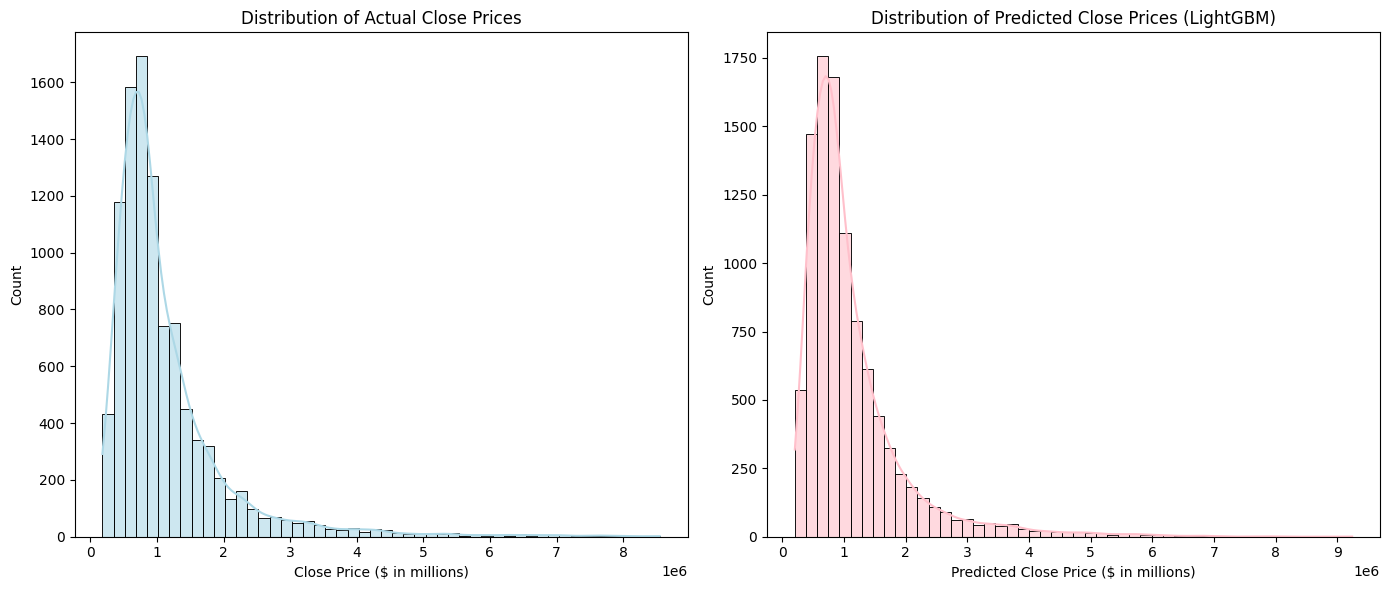

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Actual prices
plt.subplot(1, 2, 1)
sns.histplot(y_test, bins=50, kde=True, color='lightblue', alpha=0.6)
plt.title('Distribution of Actual Close Prices')
plt.xlabel('Close Price ($ in millions)')
plt.ylabel('Count')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1000000))


# Predicted prices
plt.subplot(1, 2, 2)
sns.histplot(y_pred_lgbm_dollars_best, bins=50, kde=True, color='pink', alpha=0.6)
plt.title('Distribution of Predicted Close Prices (LightGBM)')
plt.xlabel('Predicted Close Price ($ in millions)')
plt.ylabel('Count')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1000000))


plt.tight_layout()
plt.show()

In [65]:
# Feature importance from best model
importances_best_lgbm = pd.Series(
    best_lgbm.booster_.feature_importance(importance_type='gain'),
    index=best_lgbm.booster_.feature_name()
).sort_values(ascending=False)

print("Top 15 Feature Importances (LightGBM - gain):")
print(importances_best_lgbm.head(15).round(2))

Top 15 Feature Importances (LightGBM - gain):
HighSchoolDistrict_target_mean    59515.25
LivingArea_std                    32338.21
Latitude                           8310.62
dist_to_coast_km                   6305.37
Longitude                          5831.74
BathroomsTotalInteger              5576.66
Flooring_target_mean               3379.69
LotSizeSquareFeet_std              1948.89
Age                                1516.45
AssociationFee_std                 1414.89
PoolPrivateYN                       468.49
FireplaceYN                         423.42
BedroomsTotal                       422.32
GarageSpaces                        390.98
ZIP_prefix_940                      338.14
dtype: float64


In [66]:
# Evaluate which price band the model performs the best
price_bins = pd.cut(y_test, bins=[0, 500000, 1000000, 2000000, 5000000, np.inf],
                    labels=['< $500k', '$500k–1M', '$1M–2M', '$2M–5M', '> $5M'])

price_bins

0         $1M–2M
1         $2M–5M
2         $1M–2M
3         $2M–5M
4         $2M–5M
          ...   
9985    $500k–1M
9986      $1M–2M
9987    $500k–1M
9988     < $500k
9989    $500k–1M
Name: ClosePrice, Length: 9990, dtype: category
Categories (5, object): ['< $500k' < '$500k–1M' < '$1M–2M' < '$2M–5M' < '> $5M']

In [67]:
df_eval = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_lgbm_dollars_best,
    'price_band': price_bins
})

# Function to compute metrics per group
def compute_metrics(group):
    y_true = group['actual']
    y_pred = group['predicted']
    return pd.Series({
        'R²': r2_score(y_true, y_pred),
        'MAPE': np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        'MdAPE': np.median(np.abs((y_true - y_pred) / y_true)) * 100,
        'Count': len(y_true)
    }).round(4)

# Group and compute
metrics_by_band = df_eval.groupby('price_band').apply(compute_metrics).reset_index()

print("Performance by Price Band:")
print(metrics_by_band)

Performance by Price Band:
  price_band      R²     MAPE    MdAPE   Count
0    < $500k  0.0763  13.6506   8.1125  1516.0
1   $500k–1M  0.3927   9.4196   6.4023  4599.0
2     $1M–2M  0.1557  12.0334   8.8757  2843.0
3     $2M–5M  0.3387  15.2555  12.1218   921.0
4      > $5M -2.7264  21.5802  18.2798   111.0


/var/folders/l2/zp611ys113zd0f_4p1gfzfc80000gn/T/ipykernel_51373/435023244.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metrics_by_band = df_eval.groupby('price_band').apply(compute_metrics).reset_index()
/var/folders/l2/zp611ys113zd0f_4p1gfzfc80000gn/T/ipykernel_51373/435023244.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_band = df_eval.groupby('price_band').apply(compute_metrics).reset_index()


# 7. Stacking

In [419]:
# Simple equal-weight average
y_pred_log_stack = (y_pred_lgbm_log_best + y_pred_xgb_log_best + y_pred_rf_log_best) / 3

# Weighted average
weights = [0.6, 0.3, 0.1]  # e.g., LightGBM highest weight
y_pred_log_stack_weighted = (
    weights[0] * y_pred_lgbm_log_best +
    weights[1] * y_pred_xgb_log_best +
    weights[2] * y_pred_rf_log_best
)

# Convert to dollars
y_pred_dollars_stack = np.expm1(y_pred_log_stack)
y_pred_dollars_stack_weighted = np.expm1(y_pred_log_stack_weighted)

# Evaluate
# dollars
r2_stack_dollars = r2_score(y_test, y_pred_dollars_stack)
r2_stack_dollars_weighted = r2_score(y_test, y_pred_dollars_stack_weighted)

mape_stack_dollars, mdape_stack_dollars = calculate_percentage_errors(y_test, y_pred_dollars_stack)
mape_stack_dollars_weighted, mdape_stack_dollars_weighted = calculate_percentage_errors(y_test, y_pred_dollars_stack_weighted)

#log
r2_stack_log = r2_score(y_test_log, y_pred_log_stack)
r2_stack_log_weighted = r2_score(y_test_log, y_pred_log_stack_weighted)


print("Simple Averaging Stack")
print(f"R² (dollars): {r2_stack_dollars:.4f}")
print(f"MAPE: {mape_stack_dollars:.2f}%")
print(f"MdAPE: {mdape_stack_dollars:.2f}%")
print(f"R² (log): {r2_stack_log:.4f}")

print("Weighted Averaging Stack")
print(f"R² (dollars): {r2_stack_dollars_weighted:.4f}")
print(f"MAPE: {mape_stack_dollars_weighted:.2f}%")
print(f"MdAPE: {mdape_stack_dollars_weighted:.2f}%")
print(f"R² (log): {r2_stack_log_weighted:.4f}")



Simple Averaging Stack
R² (dollars): 0.8820
MAPE: 11.39%
MdAPE: 7.60%
R² (log): 0.9301
Weighted Averaging Stack
R² (dollars): 0.8870
MAPE: 11.28%
MdAPE: 7.55%
R² (log): 0.9321


# 8. Summary: Model Performance

In [45]:
data = {
    'Model': ['OLS', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'Stacking', 'Stacking (weighted)'],
    'R² (dollars)': [r2_ols_dollars, r2_tree_dollars, r2_rf_dollars_best, r2_xgb_dollars_best,r2_lgbm_dollars_best, r2_stack_dollars, r2_stack_dollars_weighted],
    'R² (log)': [r2_ols_log, r2_tree_log, r2_rf_log_best,r2_xgb_log_best, r2_lgbm_log_best, r2_stack_log, r2_stack_log_weighted],
    'MAPE (%)': [mape_ols_dollars, mape_tree_dollars, mape_rf_dollars, mape_xgb_dollars, mape_lgbm_dollars, mape_stack_dollars, mape_stack_dollars_weighted],
    'MdAPE (%)': [mdape_ols_dollars, mdape_tree_dollars, mdape_rf_dollars, mdape_xgb_dollars, mdape_lgbm_dollars, mdape_stack_dollars, mdape_stack_dollars_weighted]
}

# Create DataFrame
metrics_table = pd.DataFrame(data)

# Round numbers
metrics_table['R² (dollars)'] = metrics_table['R² (dollars)'].round(4)
metrics_table['R² (log)'] = metrics_table['R² (log)'].round(4)
metrics_table['MAPE (%)'] = metrics_table['MAPE (%)'].round(4)
metrics_table['MdAPE (%)'] = metrics_table['MdAPE (%)'].round(4)

# Display table
print("Baseline Model Comparison (log-transformed target)")
display(metrics_table)  # renders as HTML table in Colab/Jupyter



NameError: name 'r2_tree_dollars' is not defined